In [43]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


In [46]:
filename = "data/preprocessed_data2_pxrf.xlsx" # removed an outlier row which had value 196 for p

df = pd.read_excel(filename)
df.columns = df.columns.astype(str)

for i, col in enumerate(df.columns):
    print(i, col)
spectral_data = df.iloc[:, list(range(1,433))+[439]]
output_variable = df.iloc[:, 437:438]


0 NaN
1 349.866666666667
2 354.95
3 359.3
4 365.15
5 369.5
6 375.325
7 379.7
8 384.075
9 389.9
10 394.275
11 400.1
12 404.45
13 410.3
14 414.65
15 419
16 424.8
17 429.2
18 434.95
19 439.3
20 445.1
21 449.425
22 455.2
23 459.525
24 465.25
25 469.575
26 475.275
27 479.575
28 485.3
29 489.575
30 495.275
31 499.525
32 505.2
33 509.475
34 515.1
35 519.375
36 525
37 529.2
38 534.8
39 540.4
40 544.6
41 550.2
42 554.4
43 560
44 564.15
45 569.7
46 575.225
47 579.4
48 584.9
49 590.425
50 594.55
51 600.05
52 604.15
53 609.65
54 615.125
55 619.225
56 624.65
57 630.125
58 634.2
59 639.625
60 645.05
61 650.45
62 654.5
63 659.9
64 665.3
65 669.3
66 674.7
67 680.025
68 685.4
69 689.4
70 694.725
71 700.075
72 705.375
73 709.35
74 714.65
75 719.95
76 725.2
77 730.475
78 734.45
79 739.65
80 744.875
81 750.15
82 755.35
83 760.55
84 764.45
85 769.575
86 774.75
87 779.9
88 785.05
89 790.15
90 795.25
91 800.375
92 805.425
93 810.5
94 815.55
95 820.575
96 824.98
97 829.98
98 834.96
99 839.92
100 843.86
101 84

In [47]:
spectral_data.head()
output_variable.head()

,P_Wet
0,35
1,11
2,13
3,8
4,5


In [48]:
print(spectral_data.shape)
print(output_variable.shape)

(109, 433)
(109, 1)


In [49]:
output_variable.describe()

,P_Wet
count,109.000000
mean,12.293578
std,10.531525
min,0.000000
25%,5.000000
50%,8.000000
75%,16.000000
max,55.000000


Text(0.5, 1.0, 'Output P Distribution')

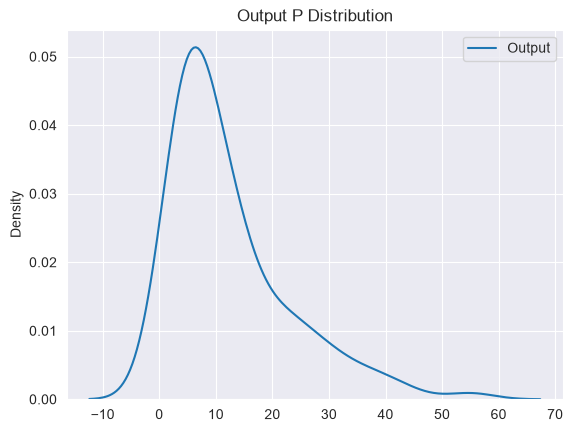

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.kdeplot(output_variable, label='Output')
plt.legend()
plt.title("Output P Distribution")

In [51]:
# skip, no need to apply filter
# from scipy.signal import savgol_filter
#
# X = savgol_filter(spectral_data.values, window_length=11, polyorder=2, deriv=1, axis=1)
y = output_variable.values.ravel()

In [52]:
# skip
# y_log = np.log1p(output_variable.values.ravel())
# sns.kdeplot(y_log)

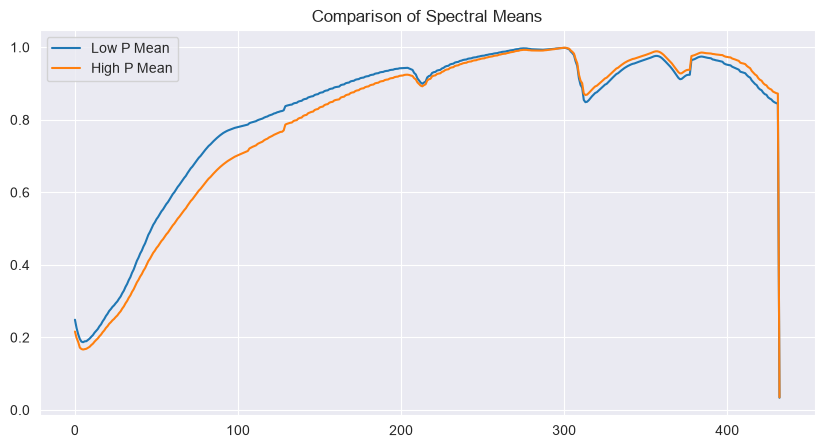

In [54]:

X_train_arr = np.array(spectral_data)

median_val = np.median(y)
low_n = X_train_arr[y <= median_val]
high_n = X_train_arr[y > median_val]

plt.figure(figsize=(10, 5))
plt.plot(np.mean(low_n, axis=0), label='Low P Mean')
plt.plot(np.mean(high_n, axis=0), label='High P Mean')
plt.legend()
plt.title("Comparison of Spectral Means")
plt.show()

In [62]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('pca', PCA(n_components=10)),
    ('regressor', Ridge(alpha=1.0))
])

# pipeline = Pipeline([
#     ('scaler', StandardScaler()),
#     ('feat_select', SelectKBest(score_func=f_regression, k=50)),
#     ('rf', RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42))
# ])

# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('pls', PLSRegression(n_components=10))
# ])



from sklearn.base import BaseEstimator, TransformerMixin

# Standard Normal Variate
class SNV(BaseEstimator, TransformerMixin):
    def fit(self, X, y):
        return self
    def transform(self, X):
        X_arr = np.array(X)
        return (X_arr - np.mean(X_arr, axis=1, keepdims=True)) / np.std(X_arr, axis=1, keepdims=True)


# pipeline = Pipeline([
#     ('snv', SNV()),
#     ('pls', PLSRegression(n_components=10))
# ])

In [63]:
from sklearn.model_selection import LeaveOneOut, cross_val_predict

cv = LeaveOneOut()
y_pred = cross_val_predict(pipeline, spectral_data, y, cv=cv)

In [64]:
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"LOOCV R2 Score: {r2:.4f}")
print(f"LOOCV RMSE: {rmse:.4f}")

LOOCV R2 Score: 0.2981
LOOCV RMSE: 8.7826


Train/Test split

In [65]:
X_train, X_test, y_train, y_test = train_test_split(spectral_data, y, test_size=0.2, random_state=42)

In [66]:
X_train

,349.866666666667,354.95,359.3,365.15,369.5,375.325,379.7,384.075,389.9,394.275,...,2464.26666666667,2467.13333333333,2474.96666666667,2479.2,2482.06666666667,2489.8,2494,2500.3,2504.5,P_XRF
65,0.239411,0.216169,0.194070,0.188055,0.178299,0.172879,0.176096,0.175677,0.178964,0.183125,...,0.864909,0.862345,0.855211,0.851761,0.848917,0.842530,0.840525,0.839080,0.840758,0.0231
26,0.206888,0.185719,0.179242,0.163760,0.160253,0.158420,0.159874,0.158389,0.161801,0.164708,...,0.919810,0.918504,0.915176,0.910585,0.908225,0.903971,0.901022,0.902285,0.900769,0.0333
22,0.196715,0.202006,0.191002,0.167273,0.171493,0.164124,0.164546,0.167597,0.167695,0.168733,...,0.854682,0.851393,0.843429,0.843169,0.838798,0.832652,0.829882,0.822697,0.822437,0.0277
31,0.229963,0.205075,0.180498,0.172705,0.160683,0.161949,0.164780,0.163015,0.164313,0.170374,...,0.912659,0.910706,0.907020,0.901736,0.899871,0.896230,0.891701,0.890014,0.889570,0.0317
47,0.267072,0.234417,0.230043,0.212151,0.198117,0.203797,0.204435,0.203493,0.209690,0.210693,...,0.882949,0.882139,0.876428,0.872215,0.871972,0.868287,0.866748,0.862697,0.862738,0.0366
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.169979,0.159260,0.159609,0.136548,0.133469,0.139208,0.135288,0.134833,0.139033,0.137423,...,0.823908,0.820689,0.811543,0.808324,0.804871,0.801092,0.798199,0.791760,0.791713,0.0216
14,0.222353,0.197319,0.182194,0.171583,0.162161,0.161795,0.165515,0.165088,0.165484,0.171034,...,0.932591,0.929623,0.924419,0.923443,0.922345,0.916206,0.914539,0.913929,0.911490,0.0345
92,0.252655,0.242317,0.226494,0.207394,0.206231,0.202601,0.201403,0.205843,0.209050,0.211235,...,0.941453,0.938305,0.932525,0.930975,0.928249,0.923926,0.922235,0.922705,0.921154,0.0568
51,0.224164,0.221536,0.191704,0.183394,0.178138,0.173911,0.178848,0.180340,0.184317,0.188330,...,0.869522,0.868528,0.859625,0.861520,0.854796,0.847693,0.841679,0.842200,0.841726,0.0212


In [67]:

pipeline = Pipeline([
    ('snv', SNV()),
    ('pls', PLSRegression(n_components=10))
])

In [71]:


# pipeline = Pipeline([
#     ('scaler', MinMaxScaler()),
#     ('pca', PCA(n_components=10)),
#     ('regressor', Ridge(alpha=1.0))
# ])

pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('regressor', PLSRegression(n_components=10))
])

In [72]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'regressor__n_components': [5, 10, 15, 20, 25]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2')
grid.fit(X_train, y_train)

print(f"Best R2: {grid.best_score_}")

Best R2: 0.2092664379251576


In [73]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {rmse:.4f}")

R2 Score: 0.7496909736410454
RMSE: 8.7826


Feature selection using lasso

In [74]:
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor


selector = SelectFromModel(estimator=Lasso(alpha=0.05)).fit(X_train, y_train)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)


In [75]:
X_train_selected

array([[0.72158892, 0.72690398, 0.88122713],
       [0.59826224, 0.60413902, 0.93817799],
       [0.57982211, 0.58592482, 0.8760631 ],
       [0.66191555, 0.66781004, 0.92877759],
       [0.69875456, 0.70422236, 0.8981369 ],
       [0.74002015, 0.74546657, 0.899299  ],
       [0.63614312, 0.64119566, 0.94792814],
       [0.7297199 , 0.73564933, 0.84505881],
       [0.65409608, 0.65942214, 0.95966582],
       [0.80217826, 0.80651256, 0.96928206],
       [0.73190259, 0.73707763, 0.92935566],
       [0.75340515, 0.75807949, 0.92153706],
       [0.51706846, 0.52277808, 0.8896542 ],
       [0.75736723, 0.76296555, 0.85514346],
       [0.74434075, 0.74985812, 0.91464363],
       [0.68050336, 0.68711409, 0.84666667],
       [0.75125168, 0.75561729, 0.93483128],
       [0.58023684, 0.58606731, 0.89787123],
       [0.5467665 , 0.55289536, 0.88263591],
       [0.51755604, 0.52350724, 0.89153387],
       [0.60123132, 0.60766356, 0.88789512],
       [0.63586599, 0.64093422, 0.94277941],
       [0.

In [77]:

pls = PLSRegression(n_components=3)
pls.fit(X_train_selected, y_train)

# 5. Prediction & Evaluation
y_pred = pls.predict(X_test_selected)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

R2 Score: 0.5033025590708093
RMSE: 7.965552044620503


Feature Importance from RF

In [78]:

# 2. Using Random Forest importance
rf = RandomForestRegressor().fit(X_train, y_train)
selector_rf = SelectFromModel(rf, threshold='median').fit(X_train, y_train)
X_train_selected_rf = selector_rf.transform(X_train)
X_test_selected_rf = selector_rf.transform(X_test)

pls = PLSRegression(n_components=8)
pls.fit(X_train_selected_rf, y_train)

y_pred = pls.predict(X_test_selected_rf)
print(f"R2 Score: {r2_score(y_test, y_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred))}")

R2 Score: 0.7331381901986522
RMSE: 5.838659272469607


In [79]:
X_train_selected_rf

array([[0.23941068, 0.21616896, 0.19406952, ..., 0.83907966, 0.84075809,
        0.0231    ],
       [0.20688784, 0.1857188 , 0.17924171, ..., 0.90228541, 0.90076883,
        0.0333    ],
       [0.19671493, 0.2020061 , 0.19100175, ..., 0.82269688, 0.82243719,
        0.0277    ],
       ...,
       [0.25265483, 0.24231745, 0.22649422, ..., 0.92270463, 0.92115403,
        0.0568    ],
       [0.22416365, 0.22153562, 0.19170396, ..., 0.84219997, 0.84172645,
        0.0212    ],
       [0.25528127, 0.23970449, 0.22050795, ..., 0.88555265, 0.88499881,
        0.0331    ]], shape=(87, 217))

In [80]:
mask = selector_rf.get_support()

selected_columns = X_train.columns[mask]

# 3. View the results
print(f"Number of features selected: {len(selected_columns)}")
print("Selected columns (wavelengths):")
print(selected_columns)

Number of features selected: 217
Selected columns (wavelengths):
Index(['349.866666666667', '354.95', '359.3', '365.15', '369.5', '375.325',
       '445.1', '449.425', '469.575', '485.3',
       ...
       '2347.6', '2350.66666666667', '2353.7', '2372.6', '2409.9',
       '2452.13333333333', '2464.26666666667', '2500.3', '2504.5', 'P_XRF'],
      dtype='str', length=217)


RF with GridSearchCV

In [81]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

# Define a pipeline
pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    # ('pca', PCA(n_components=10)),
    ('model', RandomForestRegressor(random_state=42))
])

# Define parameters to tune
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5, 10]
}

# Use 5-fold Cross-Validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Grid search
grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring='r2')
grid.fit(X_train, y_train)

print(f"Best parameters: {grid.best_params_}")
print(f"Best CV RMSE: {-grid.best_score_}")

Best parameters: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV RMSE: -0.11782849872189438


In [82]:
best_rf = grid.best_estimator_

In [83]:
y_test_pred = best_rf.predict(X_test)

print("Test R²:", r2_score(y_test, y_test_pred))
print("Test MSE:", mean_squared_error(y_test, y_test_pred))

Test R²: 0.5734570123886651
Test MSE: 54.48822280585457
